## 1. What this notebook computes

This notebook studies the **metric of the primordial gravitational field**, the
$8 \times 8$ matrix that the author wrote down and on which every later computation
of the book is built. It

- reads the metric **exactly as the author typed it** (the text is stored in the
  Revision record `Revision/gkd_lovelock/results/curvature.json`) and turns the text
  into an exact sympy matrix, step by step;
- checks the eight diagonal entries, the determinant $\det g = \cos^2 z$ and
  $\sqrt{|\det g|} = \cos z$ against the Revision records;
- checks the **signature** (4,4): four space-like directions $x_1, x_2, x_3, x_8$ and
  four time-like directions $x_4, x_5, x_6, x_7$;
- builds the diagonal **vielbein** (the scale factors) and checks that it reproduces
  the metric;
- computes the **expansion rate** of every direction: 3-space expands with the rate
  $a_4'$, the three extra times shrink (deflate) with the rate $-a_4'$;
- draws the scale factors along the **deflating history** $a_4 = A H x_4$ that the
  Revision Kohn-Sham work uses as a prescribed background ($A = 1$, $H = 1$);
- computes the **proper volumes** (3-space grows like $e^{3 a_4}$, the extra times
  shrink like $e^{-3 a_4}$, the 7-volume stays constant) and the **hidden coordinate**
  $y = \ln(\sin z)/(6H)$ in which the metric takes its warped form;
- draws 7 figures and prints a PASS line for every check.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 03a (The author's metric: signature, scale factors, warp and proper volumes) is
the file `Revision/textbook/notebooks/03a_authors_metric.ipynb` of the repository
Dirac_claude. It reads the metric of the primordial gravitational field exactly as the
author typed it (from the Revision record of the curvature computation), turns the text
into an exact sympy matrix, and checks its diagonal entries, its determinant, its
signature (4,4) and its diagonal vielbein against the Revision records. It then computes
the expansion rate of every direction, the proper volumes and the hidden coordinate y,
and draws the metric as a heat map, its entries versus z, the scale factors of 3-space
(inflating) and of the three extra times (deflating exponentially) along the deflating
history a4 = A H x4 of the Revision Kohn-Sham work, the warp factor and the proper
volumes. It needs a computer with Windows 11, macOS or Linux, an internet connection for
the installation, the program Git, and Python 3.12 or newer (the notebooks were built
with Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy
and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 03a_authors_metric.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 03a_authors_metric.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
03a_authors_metric.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/03a.captions.json`
- `Revision/textbook/figures/03a_1_metric_heat_map.png`
- `Revision/textbook/figures/03a_2_diagonal_entries.png`
- `Revision/textbook/figures/03a_3_history_scale_factors.png`
- `Revision/textbook/figures/03a_4_hidden_direction.png`
- `Revision/textbook/figures/03a_5_scale_factor_maps.png`
- `Revision/textbook/figures/03a_6_proper_volumes.png`
- `Revision/textbook/figures/03a_7_hidden_coordinate_y.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all seven figure files exist
    ALL 27 CHECKS PASSED (notebook 03a)

and the notebook must show 7 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/03a_authors_metric.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for curvature.json or parameters.json: the notebook reads these two
  Revision records of the repository, so the folder Revision of your copy is incomplete.
  Restore it with the following command in the repository folder (or clone the repository
  again) and run the notebook again:

      git checkout -- Revision

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 03a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 03a (The author's metric: signature, scale factors, warp and proper volumes)
# is the file Revision/textbook/notebooks/03a_authors_metric.ipynb of the repository
# Dirac_claude. It reads the metric of the primordial gravitational field exactly as the
# author typed it (from the Revision record of the curvature computation), turns the text
# into an exact sympy matrix, and checks its diagonal entries, its determinant, its
# signature (4,4) and its diagonal vielbein against the Revision records. It then
# computes the expansion rate of every direction, the proper volumes and the hidden
# coordinate y, and draws the metric as a heat map, its entries versus z, the scale
# factors of 3-space (inflating) and of the three extra times (deflating exponentially)
# along the deflating history a4 = A H x4 of the Revision Kohn-Sham work, the warp factor
# and the proper volumes. It needs a computer with Windows 11, macOS or Linux, an
# internet connection for the installation, the program Git, and Python 3.12 or newer
# (the notebooks were built with Python 3.14.5) with these packages at exactly these
# versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 03a_authors_metric.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 03a_authors_metric.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 03a_authors_metric.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/03a.captions.json
# - Revision/textbook/figures/03a_1_metric_heat_map.png
# - Revision/textbook/figures/03a_2_diagonal_entries.png
# - Revision/textbook/figures/03a_3_history_scale_factors.png
# - Revision/textbook/figures/03a_4_hidden_direction.png
# - Revision/textbook/figures/03a_5_scale_factor_maps.png
# - Revision/textbook/figures/03a_6_proper_volumes.png
# - Revision/textbook/figures/03a_7_hidden_coordinate_y.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all seven figure files exist
#     ALL 27 CHECKS PASSED (notebook 03a)
#
# and the notebook must show 7 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/03a_authors_metric.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for curvature.json or parameters.json: the notebook reads these
#   two Revision records of the repository, so the folder Revision of your copy is
#   incomplete. Restore it with the following command in the repository folder (or clone
#   the repository again) and run the notebook again:
#     git checkout -- Revision
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "03a"  # this notebook: chapter 03, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 03a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** $x_1, \dots, x_8$: eight numbers that name a point of the
  8-dimensional spacetime. The author's names and roles: $x_1, x_2, x_3$ ordinary
  3-space; $x_4$ the time; $x_5, x_6, x_7$ the three **extra times**; $x_8$ the
  **hidden** space direction. (In Python lists they are counted 0 to 7.)
- **Metric** $g_{\mu\nu}$: the table of numbers (a symmetric matrix) that turns a
  small coordinate step $dx^\mu$ into a squared length,
  $ds^2 = \sum_{\mu,\nu} g_{\mu\nu}\, dx^\mu dx^\nu$. The entries may depend on the
  point.
- **Diagonal metric**: $g_{\mu\nu} = 0$ whenever $\mu \ne \nu$; then
  $ds^2 = \sum_\mu g_{\mu\mu} (dx^\mu)^2$.
- **Line element**: the formula for $ds^2$.
- **Space-like, time-like**: a step along a direction with $g_{\mu\mu} > 0$ has a
  positive squared length (space-like); with $g_{\mu\mu} < 0$ a negative one
  (time-like: it measures a time, not a distance).
- **Signature** $(p, q)$: the number $p$ of positive and $q$ of negative eigenvalues
  of the metric matrix. For a diagonal matrix the eigenvalues are the diagonal
  entries. The author's metric has signature (4,4).
- $\eta$: the flat metric with the same signs, $\eta = \mathrm{diag}(+1, +1, +1,
  -1, -1, -1, -1, +1)$ in the order $x_1, \dots, x_8$.
- **Determinant** $\det g$: for a diagonal matrix the product of its diagonal
  entries. $\sqrt{|\det g|}\, d^8x$ is the proper (true) volume of a small
  coordinate box.
- **Scale factor** of a direction: the number $h_\mu = \sqrt{|g_{\mu\mu}|}$ that
  turns a coordinate interval $\Delta x^\mu$ into a proper length
  $h_\mu \Delta x^\mu$.
- **Vielbein** $e^a{}_\mu$: a matrix with $g_{\mu\nu} = \sum_{a,b} e^a{}_\mu
  \eta_{ab} e^b{}_\nu$; for a diagonal metric the diagonal matrix of the scale
  factors.
- **Expansion rate** (Hubble rate) of a direction: $\partial_{x_4} \ln h_\mu$, the
  fraction by which its lengths grow per unit of time $x_4$.
- **Inflate, deflate**: grow, shrink exponentially. 3-space inflates; the extra
  times deflate.
- $z = 6 H x_8$: the hidden coordinate in angle form, between $0$ and $\pi/2$.
- **Patch**: the range $0 < z < \pi/2$ on which the metric is used. Its end
  $z = \pi/2$ is the **patch end**; the end $z \to 0$ is the **tip**.
- **Warp factor**: the common factor $\sin^{1/3} z = e^{2Hy}$ of the six transverse
  entries $g_{11}, g_{22}, g_{33}, g_{55}, g_{66}, g_{77}$.
- **Prescribed background**: a metric that is given and not solved for from field
  equations.
- **sympy**: the Python package for exact algebra with symbols; **numpy**: arrays of
  numbers; **matplotlib**: plots.

## 4. The physical and mathematical situation

The author's metric of the primordial gravitational field is diagonal. In the order
$x_1, \dots, x_8$ its diagonal entries are

$$g = \mathrm{diag}\bigl(e^{2a_4}\sin^{1/3}z,\ e^{2a_4}\sin^{1/3}z,\
e^{2a_4}\sin^{1/3}z,\ -1,\ -e^{-2a_4}\sin^{1/3}z,\ -e^{-2a_4}\sin^{1/3}z,\
-e^{-2a_4}\sin^{1/3}z,\ \cot^2 z\bigr),\qquad z = 6 H x_8 .$$

Here $H > 0$ is a constant of the author (a number with the unit 1/length) and
$a_4 = a_4(x_4)$ is a function of the time $x_4$ only, the **metric function**. A
prime means the derivative with respect to $x_4$: $a_4' = d a_4 / d x_4$.

The line element is therefore

$$ds^2 = e^{2a_4}\sin^{1/3}z\,(dx_1^2 + dx_2^2 + dx_3^2) - dx_4^2
- e^{-2a_4}\sin^{1/3}z\,(dx_5^2 + dx_6^2 + dx_7^2) + \cot^2 z\, dx_8^2 .$$

Read it term by term. A step $dx_1$ in 3-space has the proper length
$e^{a_4}\sin^{1/6} z\, dx_1$: when $a_4$ grows, 3-space **inflates**. A step $dx_5$
along an extra time has the proper duration $e^{-a_4}\sin^{1/6} z\, dx_5$: when $a_4$
grows, the extra times **deflate exponentially**. The time $x_4$ has the coefficient
$-1$, so a step $dx_4$ is a proper time interval of exactly $dx_4$: the clock of an
observer at rest shows $x_4$. The hidden direction has the coefficient $\cot^2 z$,
which depends on $x_8$ only.

The metric alone does not fix the function $a_4(x_4)$; the field equations of $a_4$,
derived later in the book, relate it to the energy and the pressures of the matter
that fills the spacetime. For the plots this notebook uses the simplest
member of the family, $a_4 = A H x_4$, with the values of the Revision Kohn-Sham
work: $A = 1$ and the unit of length chosen so that $H = 1$. This history is a
**prescribed background** (it is assumed, not solved for). With $A > 0$ the function
$a_4$ increases, so the extra times deflate, as the author requires.

## 5. Reading the metric exactly as the author wrote it

The Rust program `lovelock_gkd`, which computed the curvature of this metric for
the Revision record, stored the author's text of the metric in its output file
`Revision/gkd_lovelock/results/curvature.json` under the name `metricAsGiven`. The
next cell reads that file and prints the text, one row of the matrix per line (it
only starts a new line after each `},` and changes nothing else). It is written in
the language of Mathematica: `{...}` is a list (the whole matrix is a list of eight
rows, each row a list of eight entries), `exp^(...)` means $e$ to the power
$(...)$, `Sin[...]` and `Cot[...]` are the sine and the cotangent, `a4[x4]` is the
value of the function $a_4$ at $x_4$, and a blank between two factors means times.

In [2]:
import numpy as np  # arrays of numbers
import sympy as sp  # exact algebra with symbols
from sympy.parsing.sympy_parser import (implicit_multiplication, parse_expr,
                                        standard_transformations)

CURVATURE_RECORD = "Revision/gkd_lovelock/results/curvature.json"
record = json.loads(repository_file(CURVATURE_RECORD).read_text(encoding="utf-8"))
author_text = record["metricAsGiven"]  # the metric exactly as the author typed it
say(f"The metric as the author wrote it ({len(author_text)} characters):")
for line in author_text.replace("},", "},\n").split("\n"):  # one row per line
    print(line)

The metric as the author wrote it (350 characters):
{{exp^(2 a4[x4]) Sin[6 H x8]^(1/3),0,0,0,0,0,0,0},
{0,exp^(2 a4[x4]) Sin[6 H x8]^(1/3),0,0,0,0,0,0},
{0,0,exp^(2 a4[x4]) Sin[6 H x8]^(1/3),0,0,0,0,0},
{0,0,0,-1,0,0,0,0},
{0,0,0,0,-exp^(-2 a4[x4]) Sin[6 H x8]^(1/3),0,0,0},
{0,0,0,0,0,-exp^(-2 a4[x4]) Sin[6 H x8]^(1/3),0,0},
{0,0,0,0,0,0,-exp^(-2 a4[x4]) Sin[6 H x8]^(1/3),0},
{0,0,0,0,0,0,0,Cot[6 H x8]^2}}


The next cell makes the **symbols** of the computation: the eight coordinates, the
constant $H$ (declared positive), the metric function $a_4(x_4)$ (an unknown
function of $x_4$, so that sympy can differentiate it), and three plain symbols that
we use for printing: `a4p` stands for $a_4'$, `a4v` for the value of $a_4$, and `z`
for $6 H x_8$.

In [3]:
x1, x2, x3, x4, x5, x6, x7, x8 = sp.symbols("x1:9", real=True)  # 8 coordinates
COORDS = [x1, x2, x3, x4, x5, x6, x7, x8]
H = sp.symbols("H", positive=True)  # the constant of the author, H > 0
a4 = sp.Function("a4")(x4)  # the metric function: an unknown function of x4
a4p, a4v = sp.symbols("a4p a4v", real=True)  # a4p = a4 prime, a4v = value of a4
z = sp.symbols("z", positive=True)  # z = 6 H x8, for printing


def plain(expression):
    """Write the derivative of a4 as a4p, the value a4(x4) as a4v, 6 H x8 as z."""
    expression = expression.subs(sp.Derivative(a4, x4), a4p).subs(a4, a4v)
    return expression.subs(x8, z / (6 * H))  # then 6*H*x8 becomes z


say("Symbols: x1 ... x8, H > 0, the function a4(x4), and a4p, a4v, z for printing.")

Symbols: x1 ... x8, H > 0, the function a4(x4), and a4p, a4v, z for printing.


The next cell turns the author's text into Python, one rule at a time, and lets
sympy read the result. Each `replace` changes one piece of Mathematica notation into
the Python notation that sympy understands: `exp^` becomes `E^` (sympy's `E` is the
number $e = 2.718\ldots$), the square brackets of `Sin[6 H x8]` and `Cot[6 H x8]`
become round brackets, `a4[x4]` becomes `a4` (which the dictionary `names` connects to
the function $a_4(x_4)$), the curly brackets of the lists become square brackets,
and the power sign `^` becomes `**`. The option `implicit_multiplication` reads a
blank between two factors as a multiplication, as Mathematica does: `6 H x8` means
$6 \cdot H \cdot x_8$.

In [4]:
text = author_text
text = text.replace("exp^", "E^")  # e to the power ...
text = text.replace("Sin[6 H x8]", "sin(6 H x8)")  # Mathematica [ ] -> Python ( )
text = text.replace("Cot[6 H x8]", "cot(6 H x8)")
text = text.replace("a4[x4]", "a4")  # the value of the function a4 at x4
text = text.replace("{", "[").replace("}", "]")  # Mathematica lists -> Python lists
text = text.replace("^", "**")  # Mathematica power ^ -> Python power **
names = {"E": sp.E, "a4": a4, "H": H, "x8": x8, "sin": sp.sin, "cot": sp.cot}
rows = parse_expr(text, local_dict=names,
                  transformations=standard_transformations + (implicit_multiplication,))
g = sp.Matrix(rows)  # the metric of the author as an exact 8 x 8 sympy matrix
say(f"The matrix has {g.rows} rows and {g.cols} columns. Its diagonal entries:")
for k in range(8):
    say(f"  g[x{k + 1}, x{k + 1}] = {g[k, k]}")
off_diagonal = [g[i, j] for i in range(8) for j in range(8) if i != j]
check(all(entry == 0 for entry in off_diagonal),
      "the 56 entries off the diagonal are zero: the metric is diagonal")

The matrix has 8 rows and 8 columns. Its diagonal entries:
  g[x1, x1] = exp(2*a4(x4))*sin(6*H*x8)**(1/3)
  g[x2, x2] = exp(2*a4(x4))*sin(6*H*x8)**(1/3)
  g[x3, x3] = exp(2*a4(x4))*sin(6*H*x8)**(1/3)
  g[x4, x4] = -1
  g[x5, x5] = -exp(-2*a4(x4))*sin(6*H*x8)**(1/3)
  g[x6, x6] = -exp(-2*a4(x4))*sin(6*H*x8)**(1/3)
  g[x7, x7] = -exp(-2*a4(x4))*sin(6*H*x8)**(1/3)
  g[x8, x8] = cot(6*H*x8)**2
PASS the 56 entries off the diagonal are zero: the metric is diagonal


Two independent checks of this reading follow. First, the next cell types the
metric a second time by hand, from the formula of section 4 of this notebook, and
checks that the two matrices agree entry by entry (the difference of every entry
simplifies to $0$). Second, it compares each diagonal entry with the entry that the
Rust program `lovelock_gkd` wrote into the record (`metricDiagonal`, in Mathematica
notation with explicit `*` signs). The small function `from_mathematica` translates
such a record entry into sympy with the same rules as above; the check that no
square bracket is left proves that every piece of notation was translated.

In [5]:
warp = sp.sin(6 * H * x8) ** sp.Rational(1, 3)  # sin(z)^(1/3), Rational: exact 1/3
typed = sp.diag(sp.exp(2 * a4) * warp, sp.exp(2 * a4) * warp, sp.exp(2 * a4) * warp,
                -1,
                -sp.exp(-2 * a4) * warp, -sp.exp(-2 * a4) * warp,
                -sp.exp(-2 * a4) * warp,
                sp.cot(6 * H * x8) ** 2)
difference = (g - typed).applyfunc(sp.simplify)  # simplify every entry
check(difference == sp.zeros(8, 8),
      "the text of the author equals the metric typed by hand from the formula")


def from_mathematica(entry_text):
    """A record entry in Mathematica notation, as a sympy expression."""
    t = entry_text.replace("Sin[6*H*x8]", "sin(6*H*x8)")
    t = t.replace("Cot[6*H*x8]", "cot(6*H*x8)")
    t = t.replace("a4[x4]", "a4").replace("^", "**")
    if "[" in t or "]" in t:  # a piece of notation that was not translated
        raise ValueError(f"cannot translate {entry_text}")
    return parse_expr(t, local_dict=names)


agree = [sp.simplify(g[k, k] - from_mathematica(entry)) == 0
         for k, entry in enumerate(record["metricDiagonal"])]
check(len(agree) == 8 and all(agree),
      "the 8 diagonal entries equal those of the Rust program lovelock_gkd",
      record=f"{CURVATURE_RECORD}, metricDiagonal")

PASS the text of the author equals the metric typed by hand from the formula
PASS the 8 diagonal entries equal those of the Rust program lovelock_gkd
     reproduces Revision/gkd_lovelock/results/curvature.json, metricDiagonal


## 6. The determinant and the volume factor

The determinant of a diagonal matrix is the product of its diagonal entries:

$$\det g = \bigl(e^{2a_4}\sin^{1/3}z\bigr)^3 \cdot (-1) \cdot
\bigl(-e^{-2a_4}\sin^{1/3}z\bigr)^3 \cdot \cot^2 z .$$

Line by line: $\bigl(e^{2a_4}\sin^{1/3}z\bigr)^3 = e^{6a_4}\sin z$ (a power of a
product is the product of the powers); $\bigl(-e^{-2a_4}\sin^{1/3}z\bigr)^3 =
-e^{-6a_4}\sin z$ (an odd power keeps the minus sign); the two minus signs multiply
to $+1$ and $e^{6a_4} e^{-6a_4} = 1$, so $\det g = \sin^2 z \cot^2 z$; and
$\cot z = \cos z / \sin z$ gives $\det g = \cos^2 z$. On the patch
$0 < z < \pi/2$ the cosine is positive, so $\sqrt{|\det g|} = \cos z$. The function
$a_4$ has dropped out: the volume factor does not change with time. The next cell
lets sympy do the same and compares with the record (`sqrtAbsDetG`, written there as
`Sin[6*H*x8]*Cot[6*H*x8]`).

In [6]:
det_g = g.det()  # the product of the diagonal entries; sympy cancels exp(6 a4)
say(f"det g = {plain(det_g)}")
check(sp.simplify(det_g - sp.cos(6 * H * x8) ** 2) == 0,
      "det g = cos(z)^2: the function a4 drops out",
      record="Revision/gkd_lovelock/results/python-lovelock-report.json, "
             "check sqrt_abs_det_g")
volume_factor = sp.cos(6 * H * x8)  # sqrt|det g| on the patch, where cos z > 0
check(sp.simplify(from_mathematica(record["sqrtAbsDetG"]) - volume_factor) == 0,
      "sqrt|det g| = sin(z) cot(z) = cos(z)",
      record=f"{CURVATURE_RECORD}, sqrtAbsDetG")
# numbers: sqrt(|det g|) at 7 points of the patch, compared with cos z
z_points = np.linspace(0.1, 1.5, 7)
det_numbers = np.array([float(det_g.subs({H: 1, x8: zp / 6})) for zp in z_points])
check(np.max(np.abs(np.sqrt(np.abs(det_numbers)) - np.cos(z_points))) < 1e-14,
      "sqrt|det g| equals cos z at 7 points of the patch")

det g = sin(z)**2*cot(z)**2
PASS det g = cos(z)^2: the function a4 drops out
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json, check
    sqrt_abs_det_g
PASS sqrt|det g| = sin(z) cot(z) = cos(z)
     reproduces Revision/gkd_lovelock/results/curvature.json, sqrtAbsDetG
PASS sqrt|det g| equals cos z at 7 points of the patch


## 7. The signature (4,4)

For a diagonal matrix the eigenvalues are the diagonal entries, so the signature is
read off the signs of the eight entries. The next cell turns the eight entries into
fast numerical functions of $z$ and of the value $a_4$ (`sp.lambdify`), evaluates
them on a grid of 400 values of $z$ strictly inside the patch and 13 values of $a_4$
from $-3$ to $3$, and checks that the sign pattern is always that of
$\eta = (+,+,+,-,-,-,-,+)$: four positive and four negative entries. It also checks
two vectors: a step along $x_1$ has a positive squared length (space-like), a step
along $x_5$ a negative one (time-like).

In [7]:
ETA = np.array([1, 1, 1, -1, -1, -1, -1, 1])  # the flat metric diag(+,+,+,-,-,-,-,+)
diagonal_z = [plain(g[k, k]) for k in range(8)]  # the entries as functions of z, a4v
functions = [sp.lambdify((z, a4v), entry, "numpy") for entry in diagonal_z]


def diagonal_values(z_values, a4_value):
    """The 8 diagonal entries at the points z_values (one row per entry)."""
    return np.array([np.broadcast_to(f(z_values, a4_value), z_values.shape)
                     for f in functions], dtype=float)


z_grid = np.linspace(0.0, np.pi / 2, 402)[1:-1]  # 400 points strictly inside
patterns = set()
for a4_value in np.linspace(-3.0, 3.0, 13):
    signs = np.sign(diagonal_values(z_grid, a4_value))  # +1 or -1 for each entry
    patterns.update(tuple(int(s) for s in column) for column in signs.T)
say(f"sign patterns found on the grid: {sorted(patterns)}")
check(patterns == {tuple(int(s) for s in ETA)},
      "on the whole grid the signs are (+,+,+,-,-,-,-,+): signature (4,4)")
step_x1 = diagonal_values(np.array([0.7]), 0.5)[0, 0]  # g11: step along x1
step_x5 = diagonal_values(np.array([0.7]), 0.5)[4, 0]  # g55: step along x5
say(f"at z = 0.7, a4 = 0.5: g11 = {step_x1:.6f} (space-like), "
    f"g55 = {step_x5:.6f} (time-like)")
check(step_x1 > 0 > step_x5, "a step along x1 is space-like, along x5 time-like")

sign patterns found on the grid: [(1, 1, 1, -1, -1, -1, -1, 1)]
PASS on the whole grid the signs are (+,+,+,-,-,-,-,+): signature (4,4)
at z = 0.7, a4 = 0.5: g11 = 2.347679 (space-like), g55 = -0.317724 (time-like)
PASS a step along x1 is space-like, along x5 time-like


The next cell sets the colours of all figures of this notebook (a palette chosen so
that the curves can be told apart also by readers with a colour-vision deficiency;
every figure also uses line styles and labels, so that it can be read in black and
white) and then draws the metric at one point, $z = \pi/4$ and $a_4 = 0.5$, as a
**heat map**: each of the $8 \times 8$ entries is a coloured square, red for
positive, blue for negative, grey for zero, and its value is written in it.

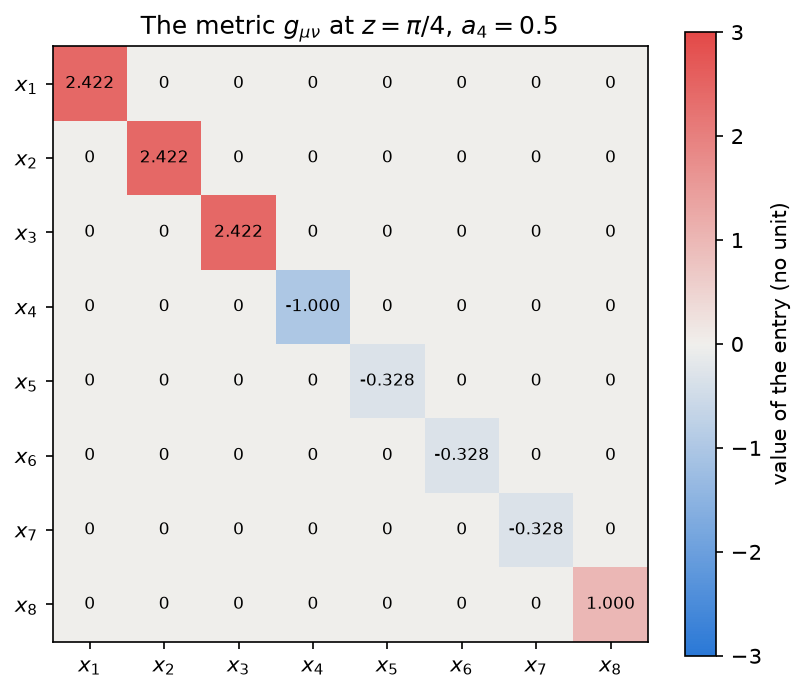

Figure 03a.1 saved as Revision/textbook/figures/03a_1_metric_heat_map.png
PASS g11 at z = pi/4, a4 = 0.5 equals e times (sin pi/4)^(1/3)


In [8]:
from matplotlib.colors import LinearSegmentedColormap

BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
MAGENTA, GREEN, VIOLET, RED = "#e87ba4", "#008300", "#4a3aa7", "#e34948"
GREY = "#f0efec"  # the neutral middle of the two-sided colour scale
DIVERGING = LinearSegmentedColormap.from_list("blue_grey_red", [BLUE, GREY, RED])
LABELS = [f"$x_{k}$" for k in range(1, 9)]

z_point, a4_point = np.pi / 4, 0.5
values = np.zeros((8, 8))
values[np.diag_indices(8)] = diagonal_values(np.array([z_point]), a4_point)[:, 0]
fig, ax = plt.subplots(figsize=(6.4, 5.4))
image = ax.imshow(values, cmap=DIVERGING, vmin=-3.0, vmax=3.0)
for i in range(8):
    for j in range(8):
        ax.text(j, i, f"{values[i, j]:.3f}" if i == j else "0", ha="center",
                va="center", fontsize=8)
ax.set_xticks(range(8), LABELS)
ax.set_yticks(range(8), LABELS)
ax.grid(False)  # no grid lines across the squares
ax.set_title("The metric $g_{\\mu\\nu}$ at $z = \\pi/4$, $a_4 = 0.5$")
fig.colorbar(image, ax=ax, label="value of the entry (no unit)")
save_figure(fig, "metric_heat_map",
            "The author's metric $g_{\\mu\\nu}$ at the point $z = 6Hx_8 = \\pi/4$ "
            "with $a_4 = 0.5$, drawn as a heat map: row $\\mu$ and column $\\nu$ run "
            "over the coordinates $x_1$ to $x_8$, red squares are positive entries, "
            "blue squares negative ones, grey squares zero; the number in each "
            "square is the entry. Only the diagonal is non-zero; the three 3-space "
            "entries are equal, $e^{1}\\,(\\sin \\pi/4)^{1/3} = 2.422$, the three "
            "extra-time entries are equal, $-e^{-1}(\\sin \\pi/4)^{1/3} = -0.328$, "
            "the time entry is $-1$ and the hidden entry is $\\cot^2(\\pi/4) = 1$: "
            "four positive and four negative entries, the signature (4,4).")
check(abs(values[0, 0] - np.e * np.sin(np.pi / 4) ** (1 / 3)) < 1e-12,
      "g11 at z = pi/4, a4 = 0.5 equals e times (sin pi/4)^(1/3)")

The next cell draws the eight diagonal entries as functions of $z$ across the whole
patch, for $a_4 = 0.5$, together with the determinant $\cos^2 z$. Entries that are
equal are drawn as one curve. The hidden entry $\cot^2 z$ grows without bound
towards the tip $z \to 0$ and vanishes at the patch end $z = \pi/2$, where the
determinant vanishes too: there the coordinate $x_8$ stops being a good coordinate.

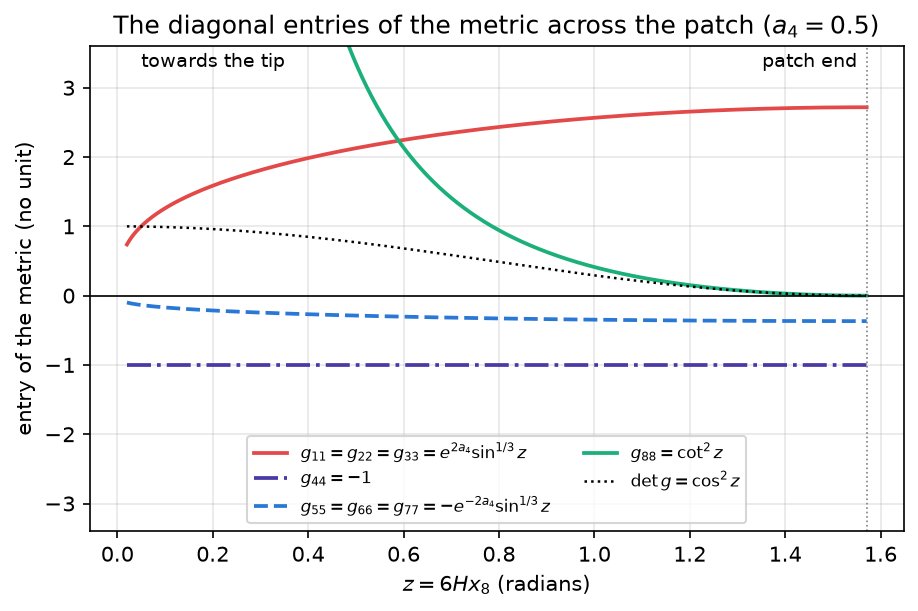

Figure 03a.2 saved as Revision/textbook/figures/03a_2_diagonal_entries.png
PASS g88 > 0 inside the patch and det g = 0 at the patch end


In [9]:
z_line = np.linspace(0.02, np.pi / 2, 600)
entries = diagonal_values(z_line, 0.5)
fig, ax = plt.subplots()
ax.plot(z_line, entries[0], color=RED, lw=1.8,
        label="$g_{11} = g_{22} = g_{33} = e^{2a_4}\\sin^{1/3}z$")
ax.plot(z_line, entries[3], color=VIOLET, lw=1.8, ls="-.", label="$g_{44} = -1$")
ax.plot(z_line, entries[4], color=BLUE, lw=1.8, ls="--",
        label="$g_{55} = g_{66} = g_{77} = -e^{-2a_4}\\sin^{1/3}z$")
ax.plot(z_line, entries[7], color=AQUA, lw=1.8, label="$g_{88} = \\cot^2 z$")
ax.plot(z_line, np.cos(z_line) ** 2, color="black", lw=1.2, ls=":",
        label="$\\det g = \\cos^2 z$")
ax.axhline(0.0, color="black", lw=0.8)
ax.axvline(np.pi / 2, color="grey", lw=0.8, ls=":")
ax.text(np.pi / 2 - 0.02, 3.3, "patch end", ha="right", fontsize=9)
ax.text(0.05, 3.3, "towards the tip", fontsize=9)
ax.set_ylim(-3.4, 3.6)  # room below the curves for the legend
ax.set_xlabel("$z = 6 H x_8$ (radians)")
ax.set_ylabel("entry of the metric (no unit)")
ax.set_title("The diagonal entries of the metric across the patch ($a_4 = 0.5$)")
ax.legend(fontsize=8, loc="lower center", ncol=2)
save_figure(fig, "diagonal_entries",
            "The diagonal entries of the author's metric as functions of "
            "$z = 6Hx_8$ from the tip side to the patch end $z = \\pi/2$, for "
            "$a_4 = 0.5$; horizontal axis $z$ in radians, vertical axis the value of "
            "the entry (pure numbers). The three 3-space entries (solid red) stay "
            "positive and the three extra-time entries (dashed blue) and the time "
            "entry (dash-dotted) stay negative everywhere, so the signature is (4,4) "
            "at every point; the hidden entry $\\cot^2 z$ (aqua) grows without bound "
            "towards the tip and reaches $0$ at the patch end, where the determinant "
            "$\\cos^2 z$ (dotted) also vanishes.")
check(np.all(entries[7] > 0) and np.cos(np.pi / 2) ** 2 < 1e-30,
      "g88 > 0 inside the patch and det g = 0 at the patch end")

## 8. The vielbein: the scale factor of each direction

Write each diagonal entry as a sign times a square: $g_{\mu\mu} = \eta_{\mu\mu}
h_\mu^2$ with a positive **scale factor** $h_\mu$. On the patch all the factors below
are positive (and $\cot z > 0$), so

$$h = \bigl(e^{a_4}\sin^{1/6}z,\ e^{a_4}\sin^{1/6}z,\ e^{a_4}\sin^{1/6}z,\ 1,\
e^{-a_4}\sin^{1/6}z,\ e^{-a_4}\sin^{1/6}z,\ e^{-a_4}\sin^{1/6}z,\ \cot z\bigr).$$

The diagonal matrix of these numbers is the **vielbein** $e^a{}_\mu$ used for the
spinors later in the book. The next cell checks $\eta_{\mu\mu} h_\mu^2 = g_{\mu\mu}$
for all eight directions; the lead's independent check of the Revision record did
the same.

In [10]:
sixth = sp.sin(6 * H * x8) ** sp.Rational(1, 6)  # sin(z)^(1/6)
h = [sp.exp(a4) * sixth] * 3 + [sp.Integer(1)] + [sp.exp(-a4) * sixth] * 3 \
    + [sp.cot(6 * H * x8)]
for k in range(8):
    say(f"  h[x{k + 1}] = {plain(h[k])}")
check(all(sp.simplify(int(ETA[k]) * h[k] ** 2 - g[k, k]) == 0 for k in range(8)),
      "eta times h squared reproduces every diagonal entry of the metric",
      record="Revision/lead_checks/reports/emt-divergence-and-spin-connection.json, "
             "check vielbein_reproduces_metric")

  h[x1] = exp(a4v)*sin(z)**(1/6)
  h[x2] = exp(a4v)*sin(z)**(1/6)
  h[x3] = exp(a4v)*sin(z)**(1/6)
  h[x4] = 1
  h[x5] = exp(-a4v)*sin(z)**(1/6)
  h[x6] = exp(-a4v)*sin(z)**(1/6)
  h[x7] = exp(-a4v)*sin(z)**(1/6)
  h[x8] = cot(z)
PASS eta times h squared reproduces every diagonal entry of the metric
     reproduces Revision/lead_checks/reports/emt-divergence-and-spin-connection.json,
    check vielbein_reproduces_metric


## 9. The expansion rate of each direction

The proper length of a coordinate interval $\Delta x_\mu$ is $h_\mu \Delta x_\mu$.
Its relative growth per unit time is $\partial_{x_4} \ln h_\mu$. For 3-space,
$\ln h_1 = a_4 + \tfrac16 \ln \sin z$, and only $a_4$ depends on $x_4$, so the rate
is $a_4'$; for an extra time $\ln h_5 = -a_4 + \tfrac16 \ln \sin z$ and the rate is
$-a_4'$; $h_4$ and $h_8$ do not depend on $x_4$, so their rates are $0$. The next cell
lets sympy differentiate. It also checks that the six transverse scale factors
multiply to $\sin z$, without $a_4$: what 3-space gains, the extra times lose.

In [11]:
rates = [sp.simplify(sp.diff(sp.log(h[k]), x4)) for k in range(8)]
for k in range(8):
    say(f"  expansion rate of x{k + 1}: {plain(rates[k])}")
a4_prime = sp.Derivative(a4, x4)
check([sp.simplify(r - c * a4_prime) == 0 for r, c in
       zip(rates, [1, 1, 1, 0, -1, -1, -1, 0])] == [True] * 8,
      "3-space expands with rate a4p, the extra times shrink with rate -a4p")
transverse = sp.simplify(h[0] * h[1] * h[2] * h[4] * h[5] * h[6])
say(f"product of the six transverse scale factors = {plain(transverse)}")
check(sp.simplify(transverse - sp.sin(6 * H * x8)) == 0,
      "the six transverse scale factors multiply to sin z, without a4")

  expansion rate of x1: a4p
  expansion rate of x2: a4p
  expansion rate of x3: a4p
  expansion rate of x4: 0
  expansion rate of x5: -a4p
  expansion rate of x6: -a4p
  expansion rate of x7: -a4p
  expansion rate of x8: 0
PASS 3-space expands with rate a4p, the extra times shrink with rate -a4p
product of the six transverse scale factors = sin(z)
PASS the six transverse scale factors multiply to sin z, without a4


## 10. The deflating history of the Revision Kohn-Sham work

The next cell reads the parameters of the Revision Kohn-Sham solver
(`Revision/kohn_sham/results/parameters.json`): the constant $H$, the slope $A$ of
the history $a_4 = A H x_4$, the five values of $a_4$ (the **slices**) at which that
solver computes its states, and the tip cut-off $L$ (used in section 13 of this
notebook). It also reads the theory record of that work
(`Revision/kohn_sham/ks-theory.json`) and prints the first and the last sentence of
its statement about the **status of the history** (key `historyStatus`). The
sentence in between, not printed, says why: the field equations of $a_4$ allow the
history $a_4 = A H x_4$ only for a source with equal pressures in all directions
and a constant energy density, and the Kohn-Sham states computed along it do not
have these properties. So the history is assumed, not derived; this notebook uses
it only to draw the time dependence of the metric.

In [12]:
PARAMETERS = "Revision/kohn_sham/results/parameters.json"
parameters = json.loads(repository_file(PARAMETERS).read_text(encoding="utf-8"))
physics = parameters["physics"]
H_value, A_value = physics["H"], physics["historyA"]
slices = physics["slicesA4"]  # the values of a4 at which the solver works
L_tip = physics["L_tipCutoff"]  # the tip cut-off, in units of 1/H
say(f"H = {H_value}, A = {A_value}, slices a4 = {slices}, tip cut-off L = {L_tip}")
check(H_value == 1.0 and A_value == 1.0 and slices == [0.0, 0.5, 1.0, 1.5, 2.0],
      "the history of the record is a4 = x4 (A = 1, H = 1) with slices 0 to 2")
KS_THEORY = "Revision/kohn_sham/ks-theory.json"
ks_theory = json.loads(repository_file(KS_THEORY).read_text(encoding="utf-8"))
status = ks_theory["adiabaticity"]["historyStatus"]  # the record's own statement
sentences = status.split(". ")  # the statement, cut into its sentences
say("status of the history (record): " + sentences[0] + ".")
say(sentences[-1])  # the last sentence already ends with a full stop
check(status.startswith("PRESCRIBED BACKGROUND") and "not solved for" in status,
      "the record states that the history is a prescribed background",
      record=f"{KS_THEORY}, adiabaticity.historyStatus")

H = 1.0, A = 1.0, slices a4 = [0.0, 0.5, 1.0, 1.5, 2.0], tip cut-off L = 3.0
PASS the history of the record is a4 = x4 (A = 1, H = 1) with slices 0 to 2
status of the history (record): PRESCRIBED BACKGROUND: the history a4 = A H x4 is
    prescribed, not solved for.
The Kohn-Sham gas is therefore a test field on a prescribed background without back-
    reaction, and quantities derived along this history (energies, pressures, equations
    of state) are not consequences of the coupled field equations.
PASS the record states that the history is a prescribed background
     reproduces Revision/kohn_sham/ks-theory.json, adiabaticity.historyStatus


Along this history $a_4 = A H x_4$, so $a_4 = 0, 0.5, \dots, 2$ at
$x_4 = 0, 0.5, \dots, 2$ (in units of $1/H$). The scale factor of 3-space is
proportional to $e^{a_4}$ and that of the extra times to $e^{-a_4}$. The next cell
draws both, and their product, against $x_4$ twice: on an ordinary vertical axis
(left) and on a logarithmic one (right), on which an exponential is a straight line
whose slope is its rate ($+AH$ and $-AH$). The dots mark the five slices.

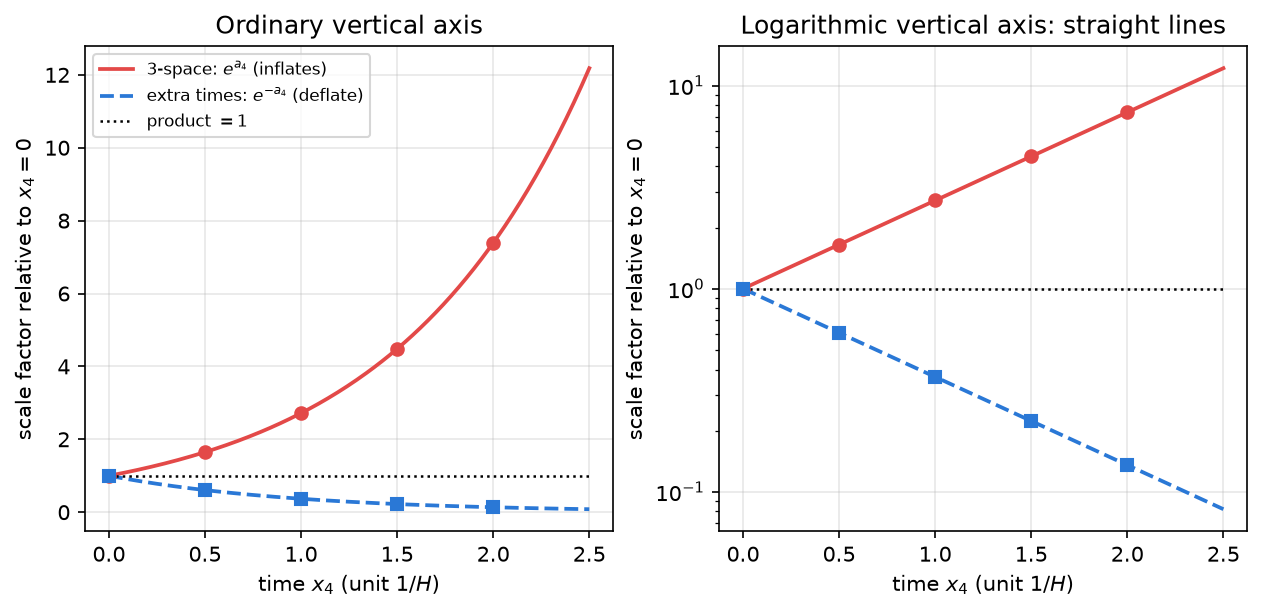

Figure 03a.3 saved as Revision/textbook/figures/03a_3_history_scale_factors.png
RESULT 3-space growth factor at the last slice a4 = 2 = 7.389056
RESULT extra-time shrink factor at the last slice a4 = 2 = 0.135335
PASS at every slice the two factors multiply to 1


In [13]:
x4_line = np.linspace(0.0, 2.5, 251)
a4_line = A_value * H_value * x4_line  # the history a4 = A H x4
slice_x4 = np.array(slices) / (A_value * H_value)  # the times of the slices
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2))
for ax, scale in zip(axes, ["linear", "log"]):
    ax.plot(x4_line, np.exp(a4_line), color=RED, lw=1.8,
            label="3-space: $e^{a_4}$ (inflates)")
    ax.plot(x4_line, np.exp(-a4_line), color=BLUE, lw=1.8, ls="--",
            label="extra times: $e^{-a_4}$ (deflate)")
    ax.plot(x4_line, np.exp(a4_line) * np.exp(-a4_line), color="black", lw=1.2,
            ls=":", label="product $= 1$")
    ax.plot(slice_x4, np.exp(slices), "o", color=RED, ms=6)
    ax.plot(slice_x4, np.exp(-np.array(slices)), "s", color=BLUE, ms=6)
    ax.set_yscale(scale)
    ax.set_xlabel("time $x_4$ (unit $1/H$)")
    ax.set_ylabel("scale factor relative to $x_4 = 0$")
axes[0].set_title("Ordinary vertical axis")
axes[1].set_title("Logarithmic vertical axis: straight lines")
axes[0].legend(fontsize=8)
save_figure(fig, "history_scale_factors",
            "The time dependence of the scale factors along the deflating history "
            "$a_4 = A H x_4$ with $A = 1$, $H = 1$ of the Revision Kohn-Sham work: "
            "3-space $e^{a_4}$ (solid red), the three extra times $e^{-a_4}$ (dashed "
            "blue) and their product (dotted black), on an ordinary (left) and a "
            "logarithmic (right) vertical axis; horizontal axis the time $x_4$ in "
            "units of $1/H$, vertical axis the factor by which lengths have grown "
            "since $x_4 = 0$ (a pure number). Dots and squares mark the five slices "
            "$a_4 = 0, 0.5, 1, 1.5, 2$. 3-space grows by $e^2 = 7.39$ and the extra "
            "times shrink to $e^{-2} = 0.135$; on the logarithmic axis both are "
            "straight lines with slopes $+1$ and $-1$, the product stays $1$.")
report("3-space growth factor at the last slice a4 = 2", f"{np.exp(2.0):.6f}")
report("extra-time shrink factor at the last slice a4 = 2", f"{np.exp(-2.0):.6f}")
check(abs(np.exp(slices[-1]) * np.exp(-slices[-1]) - 1.0) < 1e-15,
      "at every slice the two factors multiply to 1")

## 11. The hidden direction: the functions of $z$

The scale factors also depend on the hidden direction through $z$. The six
transverse directions share the factor $\sin^{1/6} z$ (their metric entries share
$\sin^{1/3} z$, the warp factor), and the hidden direction itself has the scale
factor $\cot z$ (its metric entry is $\cot^2 z$). The next cell draws these four
functions across the patch: the first two on an ordinary axis (they lie between 0
and 1 and reach 1 at the patch end), the last two on a logarithmic axis (they grow
without bound at the tip and vanish at the patch end).

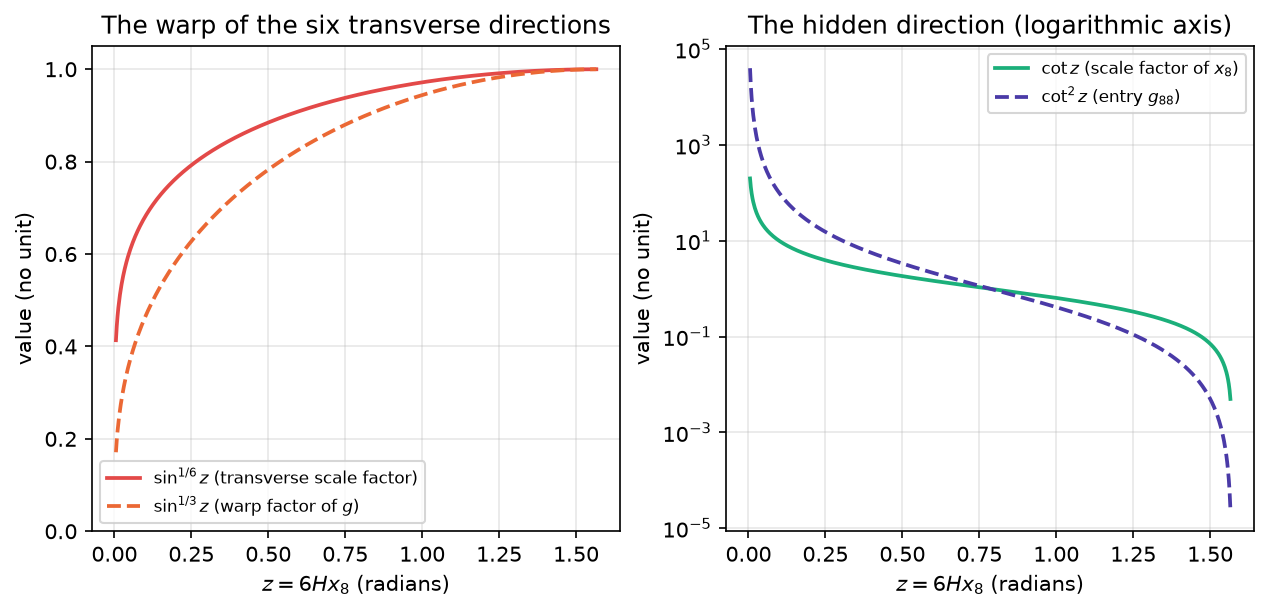

Figure 03a.4 saved as Revision/textbook/figures/03a_4_hidden_direction.png
PASS the warp factor equals 1 at the patch end z = pi/2


In [14]:
z_line = np.linspace(0.005, np.pi / 2 - 0.005, 600)
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2))
axes[0].plot(z_line, np.sin(z_line) ** (1 / 6), color=RED, lw=1.8,
             label="$\\sin^{1/6} z$ (transverse scale factor)")
axes[0].plot(z_line, np.sin(z_line) ** (1 / 3), color=ORANGE, lw=1.8, ls="--",
             label="$\\sin^{1/3} z$ (warp factor of $g$)")
axes[0].set_ylim(0.0, 1.05)
axes[0].set_title("The warp of the six transverse directions")
axes[1].plot(z_line, 1 / np.tan(z_line), color=AQUA, lw=1.8,
             label="$\\cot z$ (scale factor of $x_8$)")
axes[1].plot(z_line, 1 / np.tan(z_line) ** 2, color=VIOLET, lw=1.8, ls="--",
             label="$\\cot^2 z$ (entry $g_{88}$)")
axes[1].set_yscale("log")
axes[1].set_title("The hidden direction (logarithmic axis)")
for ax in axes:
    ax.set_xlabel("$z = 6 H x_8$ (radians)")
    ax.set_ylabel("value (no unit)")
    ax.legend(fontsize=8)
save_figure(fig, "hidden_direction",
            "The functions of the hidden coordinate $z = 6Hx_8$ in the author's "
            "metric, across the patch $0 < z < \\pi/2$; horizontal axes $z$ in "
            "radians, vertical axes pure numbers. Left: the transverse scale factor "
            "$\\sin^{1/6} z$ (solid) and the warp factor $\\sin^{1/3} z$ of the "
            "metric entries (dashed) rise from $0$ at the tip to $1$ at the patch "
            "end. Right, on a logarithmic axis: the scale factor $\\cot z$ of the "
            "hidden direction (solid) and its square $g_{88} = \\cot^2 z$ (dashed) "
            "grow without bound towards the tip and fall to $0$ at the patch end.")
check(abs(np.sin(np.pi / 2) ** (1 / 6) - 1.0) < 1e-15,
      "the warp factor equals 1 at the patch end z = pi/2")

The next cell shows how the two effects combine. It draws, over the plane of the
time $x_4$ (along the history $a_4 = x_4$) and the hidden coordinate $z$, the
logarithm to base 10 of the scale factor of 3-space, $\log_{10}(e^{a_4}\sin^{1/6}z)$
(left), and of an extra time, $\log_{10}(e^{-a_4}\sin^{1/6}z)$ (right). The value $0$
(grey) means the factor $1$; red means larger, blue smaller.

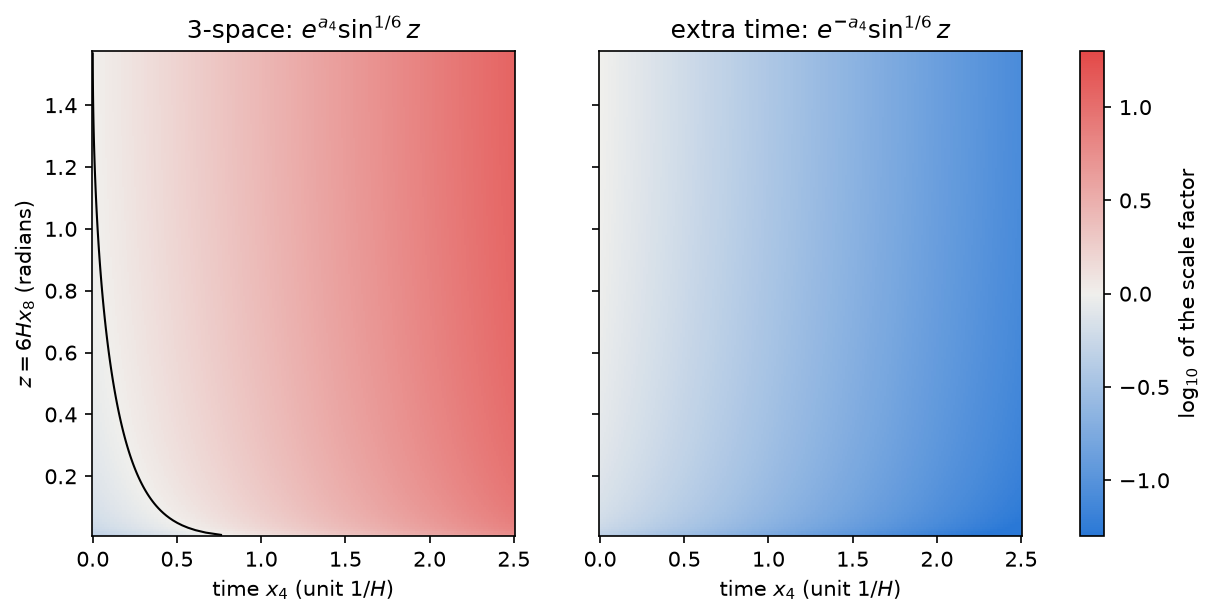

Figure 03a.5 saved as Revision/textbook/figures/03a_5_scale_factor_maps.png
PASS along the history 3-space grows and the extra times shrink at every z


In [15]:
x4_grid, z_grid2 = np.meshgrid(np.linspace(0.0, 2.5, 251),
                               np.linspace(0.01, np.pi / 2, 200))
a4_grid = A_value * H_value * x4_grid
space_map = np.log10(np.exp(a4_grid) * np.sin(z_grid2) ** (1 / 6))
extra_map = np.log10(np.exp(-a4_grid) * np.sin(z_grid2) ** (1 / 6))
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2), sharey=True)
for ax, data, title in zip(axes, [space_map, extra_map],
                           ["3-space: $e^{a_4}\\sin^{1/6}z$",
                            "extra time: $e^{-a_4}\\sin^{1/6}z$"]):
    mesh = ax.pcolormesh(x4_grid, z_grid2, data, cmap=DIVERGING, vmin=-1.3,
                         vmax=1.3, shading="auto")
    ax.contour(x4_grid, z_grid2, data, levels=[0.0], colors="black",
               linewidths=1.0)
    ax.set_title(title)
    ax.set_xlabel("time $x_4$ (unit $1/H$)")
    ax.grid(False)
axes[0].set_ylabel("$z = 6 H x_8$ (radians)")
fig.colorbar(mesh, ax=axes, label="$\\log_{10}$ of the scale factor")
save_figure(fig, "scale_factor_maps",
            "Maps of the logarithm to base 10 of the scale factor of 3-space "
            "$e^{a_4}\\sin^{1/6}z$ (left) and of an extra time "
            "$e^{-a_4}\\sin^{1/6}z$ (right) along the deflating history $a_4 = x_4$; "
            "horizontal axes the time $x_4$ in units of $1/H$, vertical axes "
            "$z = 6Hx_8$ in radians, colour the value (red above $0$: lengths larger "
            "than the coordinate interval, blue below $0$: smaller, grey and the "
            "black line: factor $1$). As time goes on, 3-space grows everywhere "
            "(left, red spreads), the extra times shrink everywhere (right, blue "
            "deepens), and near the tip $z \\to 0$ both factors are small.")
check(np.all(np.diff(space_map, axis=1) > 0) and np.all(np.diff(extra_map, axis=1) < 0),
      "along the history 3-space grows and the extra times shrink at every z")

## 12. Proper volumes: 3-space inflates, the extra times deflate, the 7-volume stays

Take a box with coordinate edges $\Delta x_1 = \Delta x_2 = \Delta x_3 = 1$. Its
proper 3-volume is the product of the three scale factors,
$V_3 = (e^{a_4}\sin^{1/6}z)^3 = e^{3a_4}\sin^{1/2}z$. The same box in the three extra
times has the proper 3-volume $V_t = e^{-3a_4}\sin^{1/2}z$, and $V_3 V_t = \sin z$.
The slice $x_4 = \mathrm{const}$ is 7-dimensional ($x_1, x_2, x_3, x_5, x_6, x_7,
x_8$); its volume factor is the product of the seven scale factors other than
$h_4 = 1$, which is $\sin z \cot z = \cos z$: it does not depend on $x_4$. The next
cell computes these products and, by an integral over the whole patch
$0 < x_8 < \pi/(12H)$, the proper 7-volume of the patch per unit coordinate volume of
the six transverse directions:
$\int_0^{\pi/(12H)} \cos(6Hx_8)\, dx_8 = \bigl[\sin(6Hx_8)/(6H)\bigr]_0^{\pi/(12H)}
= 1/(6H)$.

In [16]:
V3 = sp.simplify(h[0] * h[1] * h[2])  # proper 3-volume of a unit coordinate box
Vt = sp.simplify(h[4] * h[5] * h[6])  # the same in the three extra times
V7 = sp.simplify(h[0] * h[1] * h[2] * h[4] * h[5] * h[6] * h[7])  # the 7-volume
say(f"V3 = {plain(V3)},  Vt = {plain(Vt)},  V7 density = {plain(V7)}")
check(sp.simplify(V7 - sp.cos(6 * H * x8)) == 0 and sp.diff(V7, x4) == 0,
      "the 7-volume density is cos z and does not change with the time x4")
patch_volume = sp.integrate(sp.cos(6 * H * x8), (x8, 0, sp.pi / (12 * H)))
say(f"proper 7-volume of the patch per unit transverse coordinate volume = "
    f"{patch_volume}")
check(sp.simplify(patch_volume - 1 / (6 * H)) == 0,
      "the whole patch has the proper 7-volume 1/(6H) per unit coordinate volume")

V3 = exp(3*a4v)*sqrt(sin(z)),  Vt = exp(-3*a4v)*sqrt(sin(z)),  V7 density = cos(z)
PASS the 7-volume density is cos z and does not change with the time x4
proper 7-volume of the patch per unit transverse coordinate volume = 1/(6*H)
PASS the whole patch has the proper 7-volume 1/(6H) per unit coordinate volume


The next cell draws these volumes along the history at the fixed point
$z = \pi/3$ (where $\sin z = 0.866$ and $\cos z = 0.5$), on a logarithmic axis: $V_3$
grows like $e^{3x_4}$, $V_t$ shrinks like $e^{-3x_4}$, their product $\sin z$ and the
7-volume density $\cos z$ are constant.

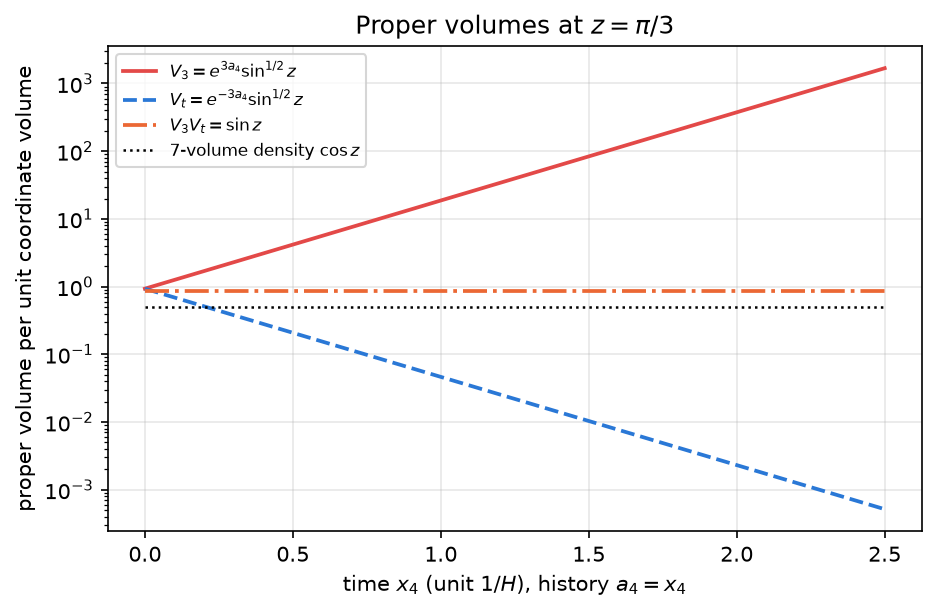

Figure 03a.6 saved as Revision/textbook/figures/03a_6_proper_volumes.png
PASS V3 times Vt stays equal to sin z along the history


In [17]:
z_fixed = np.pi / 3
v3 = np.exp(3 * a4_line) * np.sin(z_fixed) ** 0.5
vt = np.exp(-3 * a4_line) * np.sin(z_fixed) ** 0.5
fig, ax = plt.subplots()
ax.plot(x4_line, v3, color=RED, lw=1.8, label="$V_3 = e^{3a_4}\\sin^{1/2}z$")
ax.plot(x4_line, vt, color=BLUE, lw=1.8, ls="--",
        label="$V_t = e^{-3a_4}\\sin^{1/2}z$")
ax.plot(x4_line, v3 * vt, color=ORANGE, lw=1.8, ls="-.",
        label="$V_3 V_t = \\sin z$")
ax.plot(x4_line, np.full_like(x4_line, np.cos(z_fixed)), color="black", lw=1.2,
        ls=":", label="7-volume density $\\cos z$")
ax.set_yscale("log")
ax.set_xlabel("time $x_4$ (unit $1/H$), history $a_4 = x_4$")
ax.set_ylabel("proper volume per unit coordinate volume")
ax.set_title("Proper volumes at $z = \\pi/3$")
ax.legend(fontsize=8)
save_figure(fig, "proper_volumes",
            "Proper volumes per unit coordinate volume at the fixed hidden position "
            "$z = \\pi/3$ along the history $a_4 = x_4$, on a logarithmic vertical "
            "axis; horizontal axis the time $x_4$ in units of $1/H$. The proper "
            "3-volume of 3-space $V_3$ (solid red) grows like $e^{3x_4}$, the proper "
            "3-volume of the three extra times $V_t$ (dashed blue) shrinks like "
            "$e^{-3x_4}$, and both their product $\\sin z = 0.866$ (dash-dotted) and "
            "the density $\\cos z = 0.5$ of the proper 7-volume (dotted) stay "
            "constant: the inflation of 3-space is exactly compensated by the "
            "deflation of the extra times.")
check(np.max(np.abs(v3 * vt - np.sin(z_fixed))) < 1e-12,
      "V3 times Vt stays equal to sin z along the history")

## 13. The hidden coordinate $y$ and the warped form of the metric

The entry $\cot^2 z$ makes the hidden direction awkward. The Revision Kohn-Sham work
uses the coordinate $y = \ln(\sin z)/(6H)$, which measures proper distance along
$x_8$. Line by line: the chain rule gives
$dy/dx_8 = \frac{1}{6H}\,\frac{\cos z}{\sin z}\, 6H = \cot z$, so
$dy^2 = \cot^2 z\, dx_8^2 = g_{88}\, dx_8^2$; and $\sin z = e^{6Hy}$ gives
$\sin^{1/3} z = e^{2Hy}$. Hence the **warped form**

$$ds^2 = dy^2 - dx_4^2 + e^{2Hy}\bigl[e^{2a_4}(dx_1^2 + dx_2^2 + dx_3^2)
- e^{-2a_4}(dx_5^2 + dx_6^2 + dx_7^2)\bigr].$$

As $z$ runs from $0$ to $\pi/2$, $y$ runs from $-\infty$ (the tip) to $0$ (the patch
end); in $y$ the volume factor is $\sin z = e^{6Hy}$. The next cell prints the
definition stored in the record `Revision/kohn_sham/ks-theory.json` (read in
section 10) and checks these statements with sympy.

In [18]:
say("record: " + ks_theory["geometry"]["hiddenCoordinate"])
y_of_x8 = sp.log(sp.sin(6 * H * x8)) / (6 * H)  # y = ln(sin z)/(6H)
dy_dx8 = sp.diff(y_of_x8, x8)  # the chain rule, done by sympy
say(f"dy/dx8 = {plain(dy_dx8)}")
check(sp.simplify(dy_dx8 - sp.cot(6 * H * x8)) == 0,
      "dy/dx8 = cot z",
      record="Revision/lead_checks/reports/emt-divergence-and-spin-connection.json, "
             "check ks_coordinate_jacobian")
check(sp.simplify(dy_dx8 ** 2 - g[7, 7]) == 0,
      "dy^2 = g88 dx8^2: y measures proper distance along x8")
check(sp.simplify(sp.exp(2 * H * y_of_x8) - warp) == 0,
      "the warp factor sin(z)^(1/3) equals e^(2 H y)")
distance_to_end = -y_of_x8  # proper distance from the point to the patch end
check(sp.limit(distance_to_end, x8, 0, "+") == sp.oo,
      "the tip z -> 0 lies at an infinite proper distance (y -> minus infinity)")

record: y = ln(sin z)/(6H) in (-inf, 0], sin z = e^{6Hy}, dy = cot z dx8; the patch end z
    = pi/2 is y = 0, the tip z -> 0 is y -> -inf
dy/dx8 = cos(z)/sin(z)
PASS dy/dx8 = cot z
     reproduces Revision/lead_checks/reports/emt-divergence-and-spin-connection.json,
    check ks_coordinate_jacobian
PASS dy^2 = g88 dx8^2: y measures proper distance along x8
PASS the warp factor sin(z)^(1/3) equals e^(2 H y)
PASS the tip z -> 0 lies at an infinite proper distance (y -> minus infinity)


The Revision Kohn-Sham solver keeps only the part $-L \le y \le 0$ of the hidden
direction, with the tip cut-off $L = 3/H$ read in section 10. How much of the
7-volume does the cut-off remove? In $y$ the 7-volume density is $e^{6Hy}$, so the
fraction of the 7-volume beyond the cut-off is
$\int_{-\infty}^{-L} e^{6Hy} dy \big/ \int_{-\infty}^{0} e^{6Hy} dy = e^{-6HL}$,
which is $e^{-18} \approx 1.5 \times 10^{-8}$ for $L = 3/H$. The cut-off lies at the
tiny angle $z = \arcsin e^{-18} \approx 1.5 \times 10^{-8}$. The next cell computes
the fraction with sympy and draws $y$ as a function of $z$ (left; the $z$ axis is
logarithmic, so that the region near the tip is visible: there
$y \approx \ln(z)/(6H)$ is a straight line) and the warp factor $e^{2Hy}$ and the
volume density $e^{6Hy}$ as functions of $y$ (right).

RESULT fraction of the 7-volume beyond the tip cut-off y = -3 = exp(-18) = 1.5230e-08
RESULT angle z of the tip cut-off = 1.5230e-08 radians


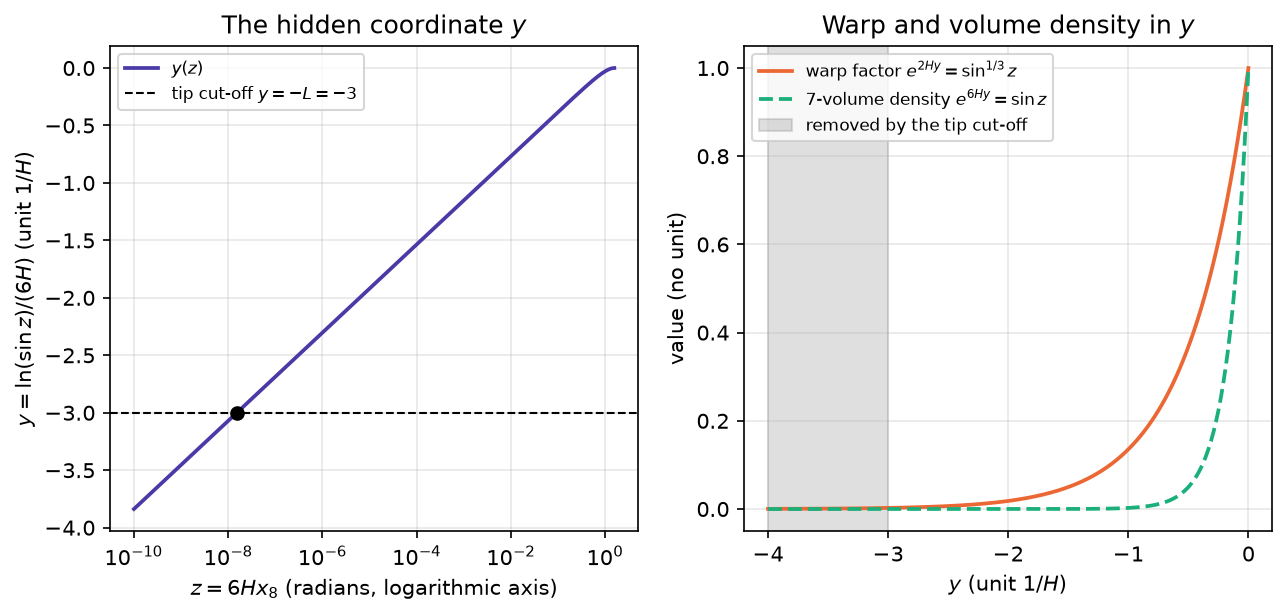

Figure 03a.7 saved as Revision/textbook/figures/03a_7_hidden_coordinate_y.png
PASS the cut-off removes exactly the fraction e^(-18)


In [19]:
ys = sp.symbols("y", real=True)
L_exact = sp.nsimplify(L_tip)  # the number 3.0 of the record as the exact integer 3
fraction = sp.integrate(sp.exp(6 * H * ys), (ys, -sp.oo, -L_exact / H)) \
    / sp.integrate(sp.exp(6 * H * ys), (ys, -sp.oo, 0))
fraction = sp.simplify(fraction.subs(H, 1))
report("fraction of the 7-volume beyond the tip cut-off y = -3", sp.sstr(fraction),
       f"= {float(fraction):.4e}")
z_cut = float(sp.asin(sp.exp(-18)))  # the angle z of the cut-off, sin z = e^(-18)
report("angle z of the tip cut-off", f"{z_cut:.4e}", "radians")
z_line = np.logspace(-10, np.log10(np.pi / 2), 800)  # 1e-10 ... pi/2, evenly in log
y_line = np.log(np.sin(z_line)) / 6.0  # with H = 1
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2))
axes[0].plot(z_line, y_line, color=VIOLET, lw=1.8, label="$y(z)$")
axes[0].axhline(-L_tip, color="black", lw=1.0, ls="--",
                label=f"tip cut-off $y = -L = -{L_tip:g}$")
axes[0].plot([z_cut], [-L_tip], "o", color="black", ms=6)
axes[0].set_xscale("log")
axes[0].set_xlabel("$z = 6 H x_8$ (radians, logarithmic axis)")
axes[0].set_ylabel("$y = \\ln(\\sin z)/(6H)$ (unit $1/H$)")
axes[0].set_title("The hidden coordinate $y$")
axes[0].legend(fontsize=8)
y_axis = np.linspace(-4.0, 0.0, 400)
axes[1].plot(y_axis, np.exp(2 * y_axis), color=ORANGE, lw=1.8,
             label="warp factor $e^{2Hy} = \\sin^{1/3} z$")
axes[1].plot(y_axis, np.exp(6 * y_axis), color=AQUA, lw=1.8, ls="--",
             label="7-volume density $e^{6Hy} = \\sin z$")
axes[1].axvspan(-4.0, -L_tip, color="grey", alpha=0.25,
                label="removed by the tip cut-off")
axes[1].set_xlabel("$y$ (unit $1/H$)")
axes[1].set_ylabel("value (no unit)")
axes[1].set_title("Warp and volume density in $y$")
axes[1].legend(fontsize=8, loc="upper left")
save_figure(fig, "hidden_coordinate_y",
            "The hidden coordinate $y = \\ln(\\sin z)/(6H)$ with $H = 1$. Left: $y$ "
            "versus $z = 6Hx_8$ in radians on a logarithmic axis from $10^{-10}$ to "
            "$\\pi/2$; $y$ is $0$ at the patch end $z = \\pi/2$ and falls without "
            "bound towards the tip $z \\to 0$, along the straight line "
            "$y \\approx \\ln(z)/6$; the dashed line and the dot mark the tip cut-off "
            "$y = -3$ of the Revision Kohn-Sham solver, at $z = 1.5 \\times "
            "10^{-8}$. Right: the "
            "warp factor $e^{2Hy}$ (solid) and the density $e^{6Hy}$ of the proper "
            "7-volume (dashed) versus $y$ in units of $1/H$; the grey band beyond "
            "the cut-off holds only the fraction $e^{-18} = 1.5 \\times 10^{-8}$ of "
            "the 7-volume of the patch.")
check(fraction == sp.exp(-18), "the cut-off removes exactly the fraction e^(-18)")

## 14. The last check

The last cell checks that the seven figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [20]:
figure_names = ["metric_heat_map", "diagonal_entries", "history_scale_factors",
                "hidden_direction", "scale_factor_maps", "proper_volumes",
                "hidden_coordinate_y"]
files = [output_file(f"{FIGURE_FOLDER}/03a_{k}_{n}.png")
         for k, n in enumerate(figure_names, 1)]
check(all(path.is_file() for path in files), "all seven figure files exist")
all_checks_passed()

PASS all seven figure files exist
ALL 27 CHECKS PASSED (notebook 03a)


## 15. What this notebook showed

- The metric was read **exactly as the author typed it**, and the text agrees with
  the formula and with the Revision record of the Rust program `lovelock_gkd`
  (all 8 diagonal entries; the 56 other entries are zero).
- $\det g = \cos^2 z$ and $\sqrt{|\det g|} = \cos z$, without $a_4$: PROVED here by
  exact algebra (and in the Revision record).
- The signature is (4,4) at every point of the patch: $x_1, x_2, x_3, x_8$ are
  space-like, $x_4, x_5, x_6, x_7$ time-like.
- The diagonal vielbein $h = (e^{a_4}\sin^{1/6}z\ (\times 3), 1,
  e^{-a_4}\sin^{1/6}z\ (\times 3), \cot z)$ reproduces the metric.
- 3-space expands with the rate $a_4'$ and the three extra times **deflate** with the
  rate $-a_4'$; along the prescribed history $a_4 = x_4$ ($A = 1$, $H = 1$) 3-space
  lengths grow by $e^2 = 7.39$ and extra-time durations shrink to $e^{-2} = 0.135$
  between the first and the last slice.
- The proper 3-volume of 3-space grows like $e^{3a_4}$, that of the extra times
  shrinks like $e^{-3a_4}$, and the 7-volume density $\cos z$ is constant in time;
  the whole patch has the 7-volume $1/(6H)$ per unit transverse coordinate volume.
- In the hidden coordinate $y = \ln(\sin z)/(6H)$ the metric has the warped form
  with warp factor $e^{2Hy}$; the tip is at infinite proper distance, and the tip
  cut-off $y = -3/H$ of the Kohn-Sham solver removes only the fraction $e^{-18}$ of
  the 7-volume.
- ASSUMED: the history $a_4 = A H x_4$ is a prescribed background (the Revision
  record says so in its own words), used here only to draw the time dependence; the
  field equations of $a_4$ come later.